# Visualizar CAMB y Simulaciones



In [1]:
import os
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from scripts.config import NSIDE, LMAX, NSIM, RUTA_0, RUTA_1

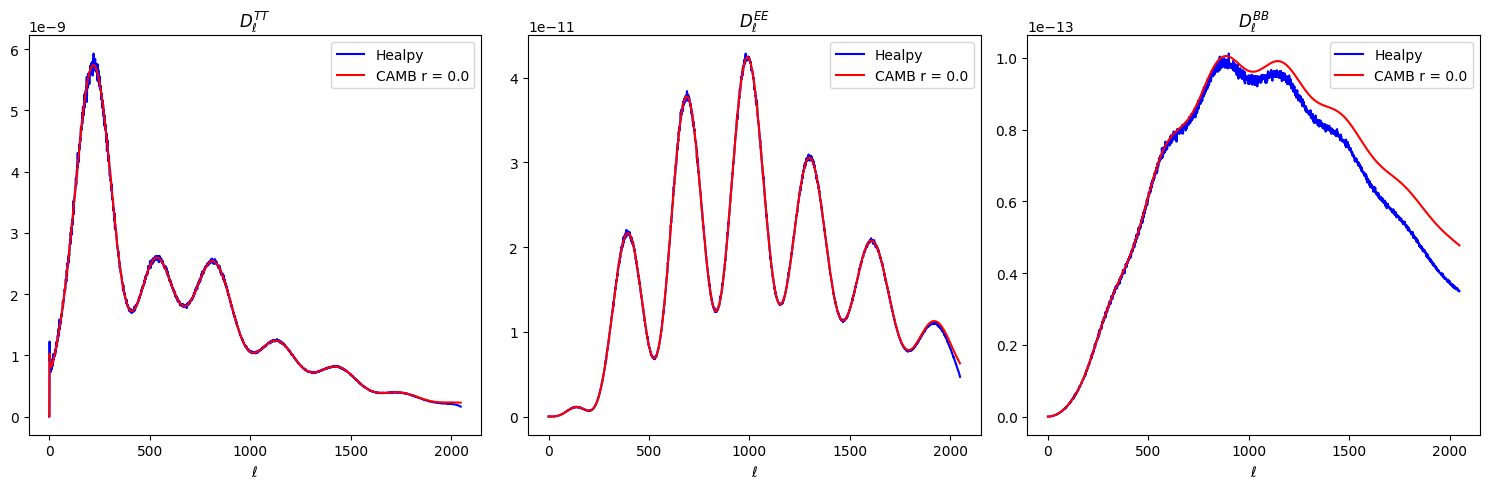

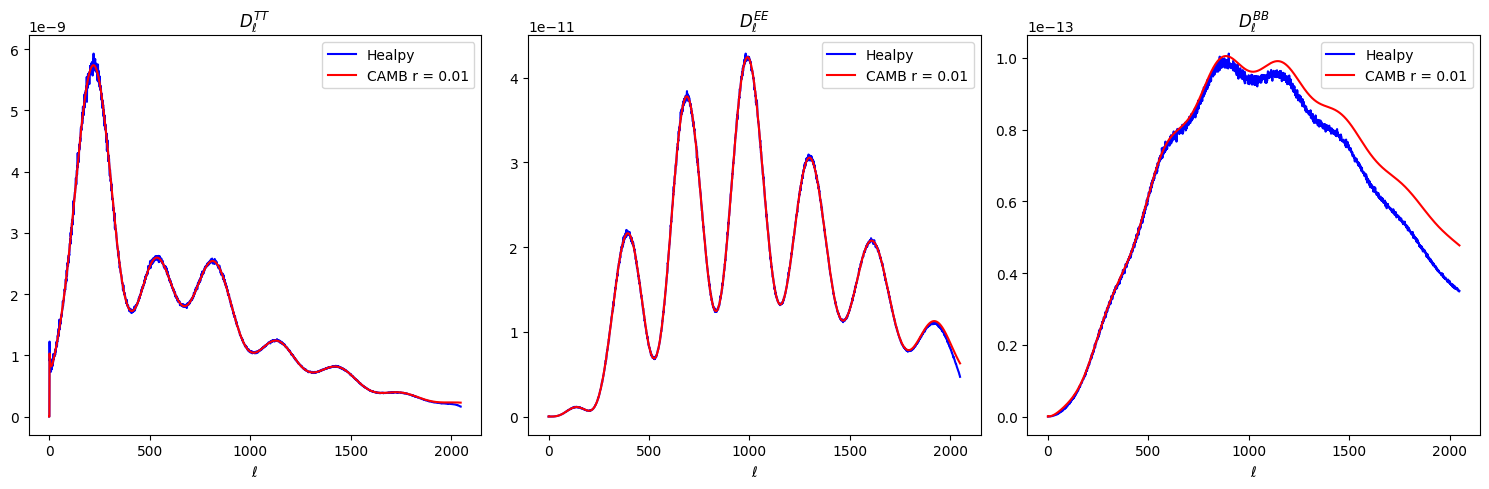

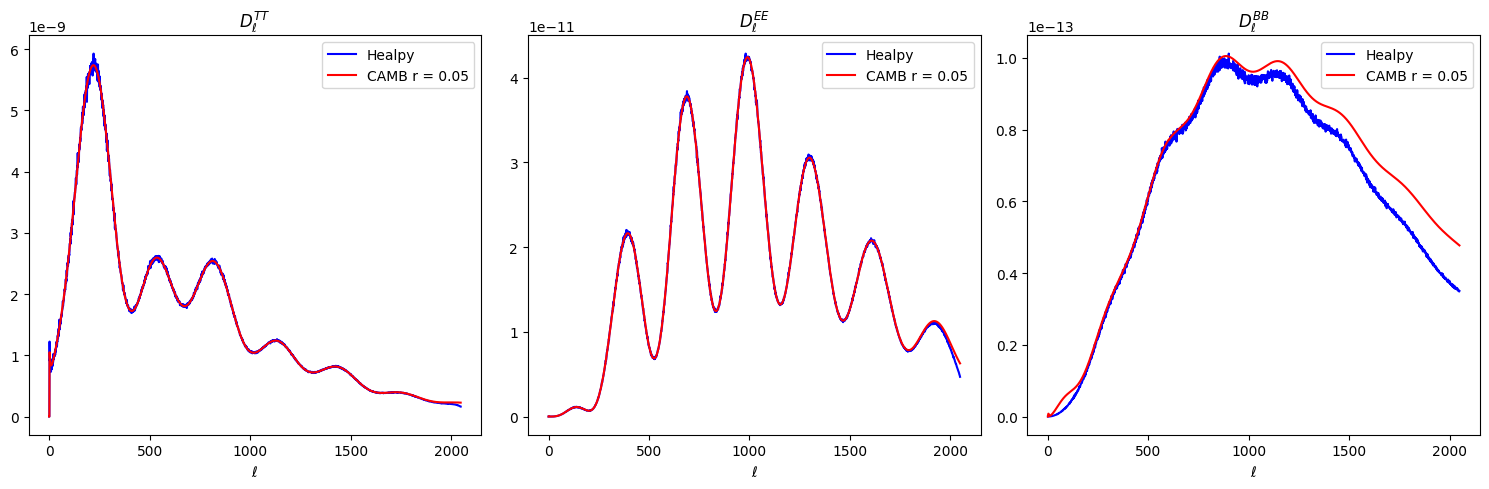

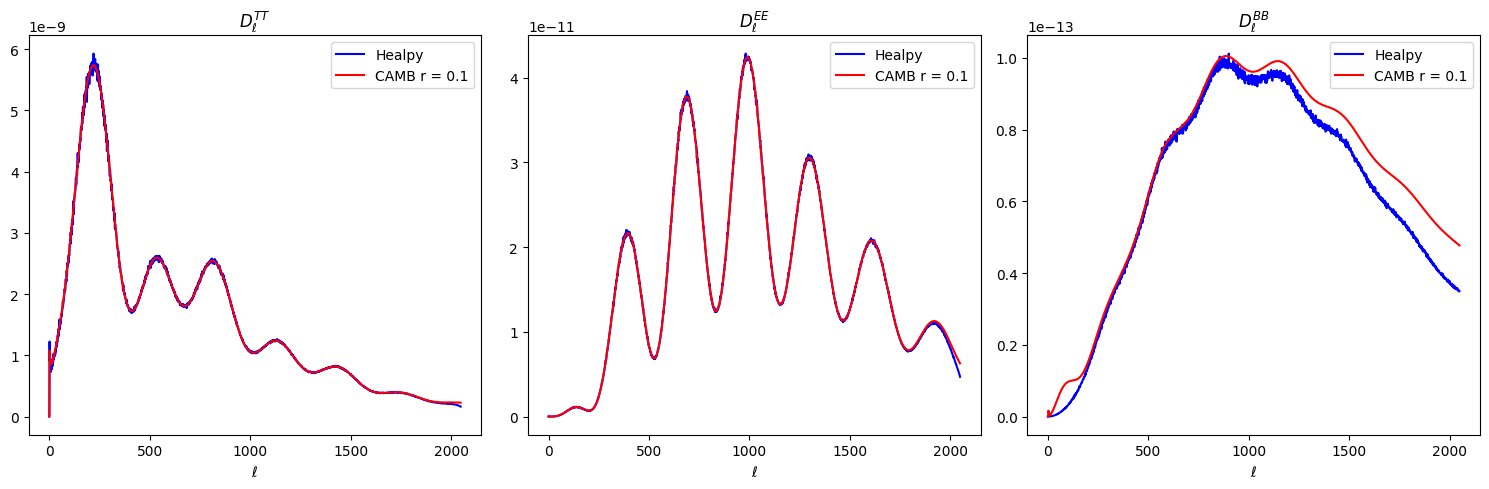

NameError: name 'Lfac' is not defined

In [ ]:
# ---------------
# Ruta de los mapas
# ---------------

ruta = RUTA_0

ruta_f = "/home/jorge/Escritorio/Proy_cosmo/Cosmo_MSc/outputs/fiducial/Foreground/"

ruta_n = "/home/jorge/Escritorio/Proy_cosmo/Cosmo_MSc/outputs/fiducial/Noise_SO"

ruta_obs = "/home/jorge/Escritorio/Proy_cosmo/Cosmo_MSc/outputs/obs_maps"

ruta_fid = "/home/jorge/Escritorio/Proy_cosmo/Cosmo_MSc/outputs/fiducial"

nside = NSIDE
lmax  = LMAX
nsim  = NSIM

vect_r = np.array([0, 0.01, 0.05, 0.1])

freq = np.array([27, 39, 93, 145, 225, 280])

names = np.array(["T", "E" , "B"])

names1 = np.array(["TT", "EE", "BB", "TE"])

# Cargamos las simulaciones para cada r
for r in vect_r:

    ruta_fid_r = os.path.join(ruta_fid, f"r_{r}")
    
    ruta_r = os.path.join(ruta, f"r_{r}")

    ells = np.loadtxt(os.path.join(ruta_r, "ells.txt"))

    factor = ells*(ells+1)/(2*np.pi) # Para graficar D_l

    mean_Cl_ls = np.zeros((3, lmax+1), dtype=float)  # TT, EE, BB
    mean_Cl_ul = np.zeros((3, lmax+1), dtype=float)
    # mean_Cl_TE = 0
    for i in range(nsim):

        data = np.load(os.path.join(ruta_r, f"cmb_alms_total{i+1}.npz")) # cargar cmb_total

        data1 = np.load(os.path.join(ruta_r, f"cmb_alms_unlensed{i+1}.npz")) # cargar cmb_unlensed

        # lista de alms orden T, E y B 
        for j, name in enumerate(names):

            alm_total = data[f"alm{name}"] 

            alm_unlensed = data1[f"alm{name}"]

            mean_Cl_ls[j] += hp.sphtfunc.alm2cl(alm_total, alm_total, lmax=lmax)*factor
            mean_Cl_ul[j] += hp.sphtfunc.alm2cl(alm_unlensed, alm_unlensed, lmax=lmax)*factor


    mean_Cl_ls = mean_Cl_ls/nsim
    mean_Cl_ul = mean_Cl_ul/nsim

    for i,name in enumerate(names):
        np.savetxt(os.path.join(ruta_fid_r, f"Mean_Cl_ls_{name}{name}.txt"), mean_Cl_ls[i])
        np.savetxt(os.path.join(ruta_fid_r, f"Mean_Cl_ul_{name}{name}.txt"), mean_Cl_ul[i])

    Cl_total = []
    Cl_unlensed = []
    for name in names1:
        tot_cl =  np.loadtxt(os.path.join(ruta_r, f"Cl_total_{name}.txt"))
        Cl_total.append(tot_cl)
        unl_cl =  np.loadtxt(os.path.join(ruta_r, f"Cl_unlensed_{name}.txt"))
        Cl_unlensed.append(unl_cl)
    
    
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))

    ax[0].plot(ells, mean_Cl_ls[0],color='b',label='Healpy') 
    ax[0].plot(ells, Cl_total[0]*factor,color="r",label=f"CAMB r = {r}")
    ax[0].set_title(r'$D_\ell^{TT}$')
    ax[0].legend()
    ax[0].set_xlabel(r'$\ell$')

    ax[1].plot(ells, mean_Cl_ls[1],color='b',label='Healpy') 
    ax[1].plot(ells, Cl_total[1]*factor,color="r",label=f"CAMB r = {r}")
    ax[1].set_title(r'$D_\ell^{EE}$')
    ax[1].legend()
    ax[1].set_xlabel(r'$\ell$')

    ax[2].plot(ells, mean_Cl_ls[2],color='b',label='Healpy') 
    ax[2].plot(ells, Cl_total[2]*factor,color="r",label=f"CAMB r = {r}")
    ax[2].set_title(r'$D_\ell^{BB}$')
    ax[2].legend()
    ax[2].set_xlabel(r'$\ell$')

    plt.tight_layout()
    plt.show()




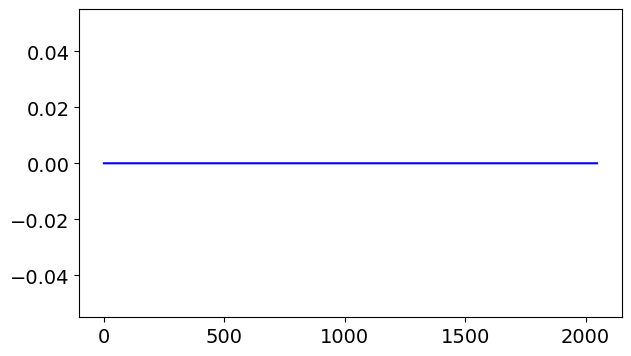

In [52]:

ruta_r = "/home/jorge/Escritorio/Proy_cosmo/Cosmo_MSc/outputs/fiducial/r_0.01"

ells = np.loadtxt(os.path.join(ruta_r, "ells.txt"))
factor = ells*(ells+1)/(2*np.pi)

tot_cl_TT =  np.loadtxt(os.path.join(ruta_r, f"Cl_total_TT.txt"))
tot_cl_EE =  np.loadtxt(os.path.join(ruta_r, f"Cl_total_EE.txt"))
tot_cl_BB =  np.loadtxt(os.path.join(ruta_r, f"Cl_total_BB.txt"))

unl_cl_BB =  np.loadtxt(os.path.join(ruta_r, f"Cl_unlensed_BB.txt"))

# plt.plot(ells, tot_cl_TT*factor, color='r',label=r'C_\ell ^{TT}')
# plt.plot(ells, tot_cl_EE*factor, color='m',label=r'C_\ell ^{EE}')
# plt.plot(ells, tot_cl_BB*factor, color='k',label=r'C_\ell ^{BB} (r + lensing)')
plt.plot(ells, unl_cl_BB*factor, color='b',label=r'C_\ell ^{TT} (r)' )


#('r','TT'),('g','TE'),('b','EE'),('y','TB'),('m','EB'),('k','MV')])


## $C_\ell^{\phi\phi}$

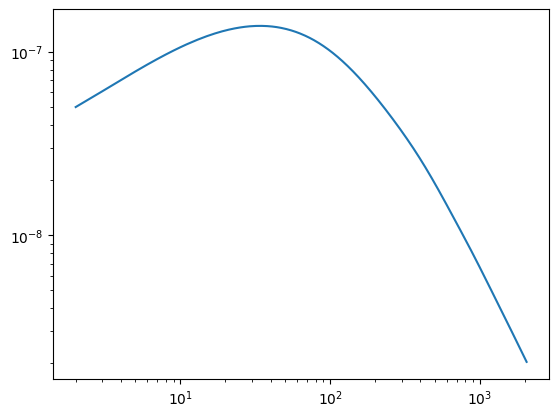

In [13]:
ruta_f = "/home/jorge/Escritorio/Proy_cosmo/Cosmo_MSc/outputs/fiducial/r_0.0"

lmax  = LMAX
L = np.linspace(0,lmax,lmax+1)
Lfac = (L*(L+1))**2/(2*np.pi)

Cl_phi = np.loadtxt(os.path.join(ruta_f, f"Cl_phiphi.txt")) # cargar phi


plt.loglog(L[2:], Cl_phi[2:]*Lfac[2:])
plt.show()

# Mapas T, Q, U y $\phi$

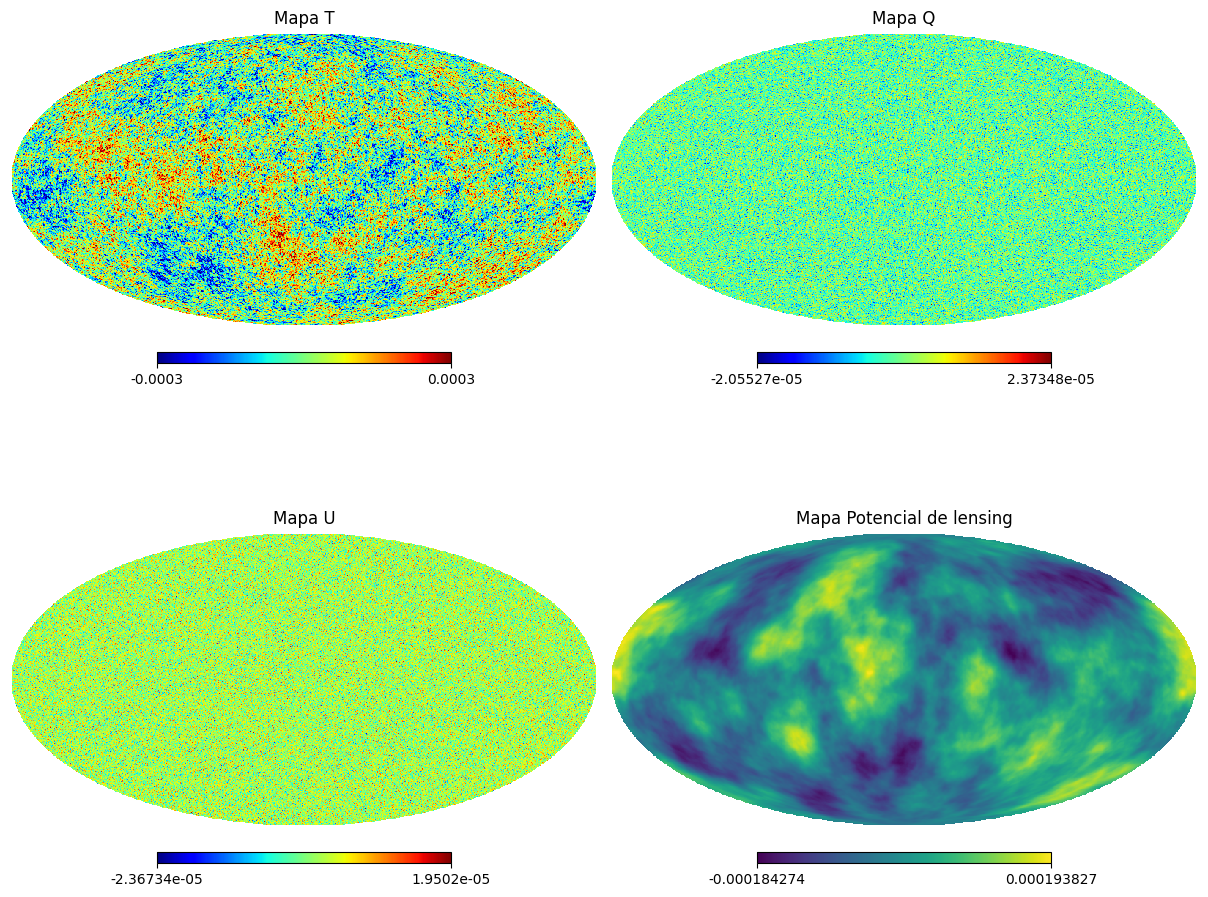

In [5]:

vect_r = np.array([0, 0.01, 0.05, 0.1])

# Modificar la ruta para mapas de otro valor de r
ruta_r = "/home/jorge/Escritorio/Proy_cosmo/Cosmo_MSc/outputs/fiducial/r_0.0"

nside = NSIDE
lmax  = LMAX
nsim  = NSIM

names = np.array(["T", "E" , "B"])

data = np.load(os.path.join(ruta_r, f"cmb_alms_total{5}.npz")) # cargar cmb_total

data1 = np.load(os.path.join(ruta_r, f"cmb_alms_unlensed{5}.npz")) # cargar cmb_unlensed

data2 = np.load(os.path.join(ruta_r, f"cmb_alms_phi{5}.npz")) # cargar phi
alm_phi = data2["alm_phi"]

alms_total = []
alms_unlensed = []
for name in names:

    alm = data[f"alm{name}"] 
    alms_total.append(alm)
    
    alm1 = data1[f"alm{name}"] 
    alms_unlensed.append(alm1)

map_total_T, map_total_Q, map_total_U = hp.alm2map(alms_total, nside=nside, lmax=lmax ,pol=True)
map_unlensed_T, map_unlensed_Q, map_unlensed_U = hp.alm2map(alms_unlensed, nside=nside, lmax=lmax, pol=True)
map_phi = hp.alm2map(alm_phi, nside=nside, lmax=lmax)

plt.figure(figsize=(12,10))

hp.mollview(map_total_T, title="Mapa T", min=-3e-4, max=3e-4, sub=(2,2,1), cmap = "jet")
hp.mollview(map_total_Q, title="Mapa Q", sub=(2,2,2), cmap = "jet")
hp.mollview(map_total_U, title="Mapa U", sub=(2,2,3), cmap = "jet")
hp.mollview(map_phi, title="Mapa Potencial de lensing",sub=(2,2,4))
plt.show()

# L = np.linspace(0,lmax,lmax+1)
# Lfac = (L*(L+1.))**2/(2*np.pi)
# cl_phi = hp.alm2cl(alm_phi,lmax=lmax)
# plt.plot(L[:1000],Lfac[:1000]*cl_phi[:1000],color="black",ls='-',label='input')


# Mapas observados 

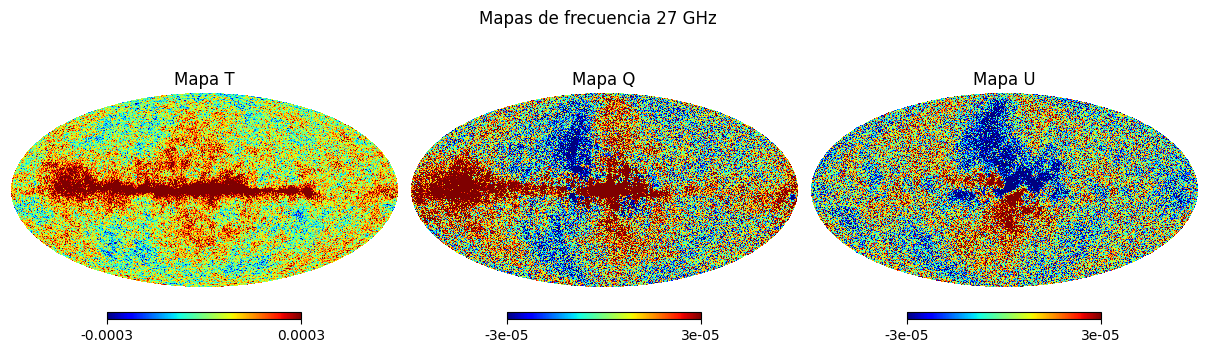

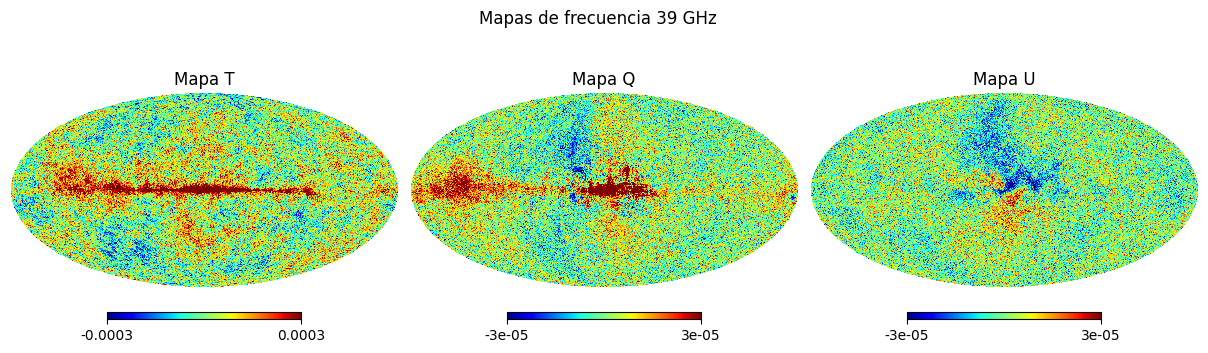

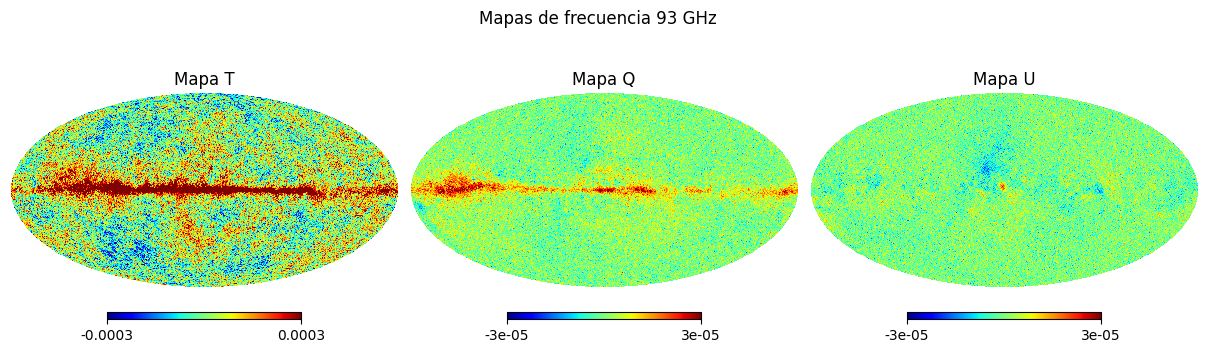

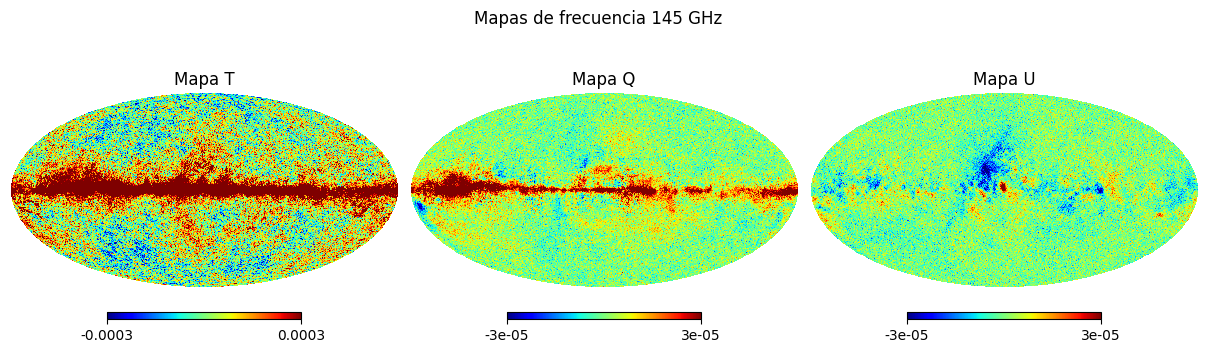

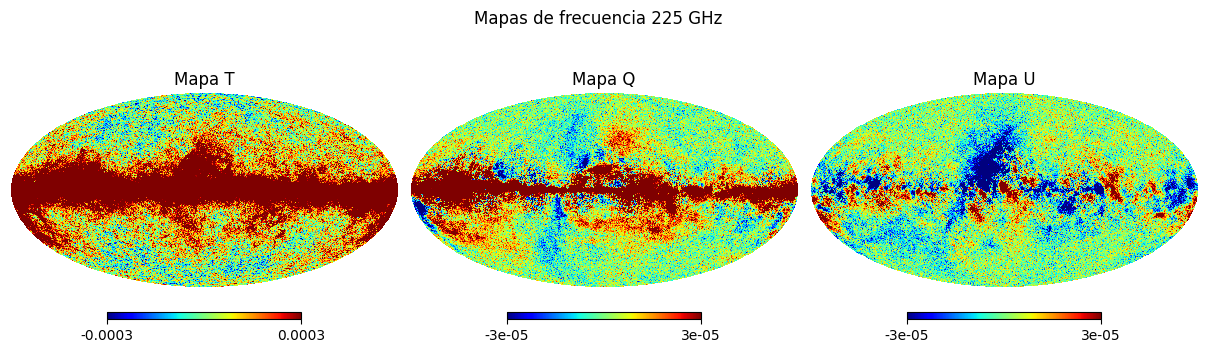

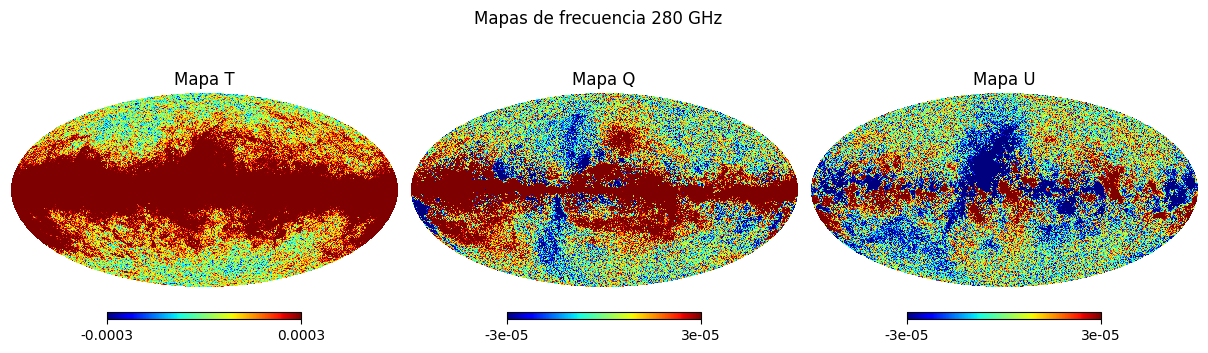

In [5]:

ruta_obs = "/home/jorge/Escritorio/Proy_cosmo/Cosmo_MSc/outputs/obs_maps/r_0.0"

nside = NSIDE
lmax  = LMAX
nsim  = NSIM

vect_r = np.array([0, 0.01, 0.05, 0.1])

freq = np.array([27, 39, 93, 145, 225, 280])

names = np.array(["T", "E" , "B"])

names1 = np.array(["TT", "EE", "BB", "TE"])



for f in freq:

    data = np.load(os.path.join(ruta_obs, f"alm_obs_{f}_LAT{5}.npz")) # alm mapas observados

    alms = []
    for name in names:

        alm = data[f"alm{name}"] 
        alms.append(alm)


    map_obs_T, map_obs_Q, map_obs_U = hp.alm2map(alms, nside=nside, lmax=lmax ,pol=True)

    plt.figure(figsize=(12,10))
    plt.suptitle(f"Mapas de frecuencia {f} GHz",y=0.85) #El y controla que tan arriba queda
    hp.mollview(map_obs_T, title="Mapa T", min=-3e-4, max=3e-4, sub=(2,3,1), cmap = "jet")
    hp.mollview(map_obs_Q, title="Mapa Q", min=-3e-5, max=3e-5,sub=(2,3,2), cmap = "jet")
    hp.mollview(map_obs_U, title="Mapa U", min=-3e-5, max=3e-5,sub=(2,3,3), cmap = "jet")
    plt.show()





# Mapas HILC y ruido residual promedio $\left< N_\ell \right>$.

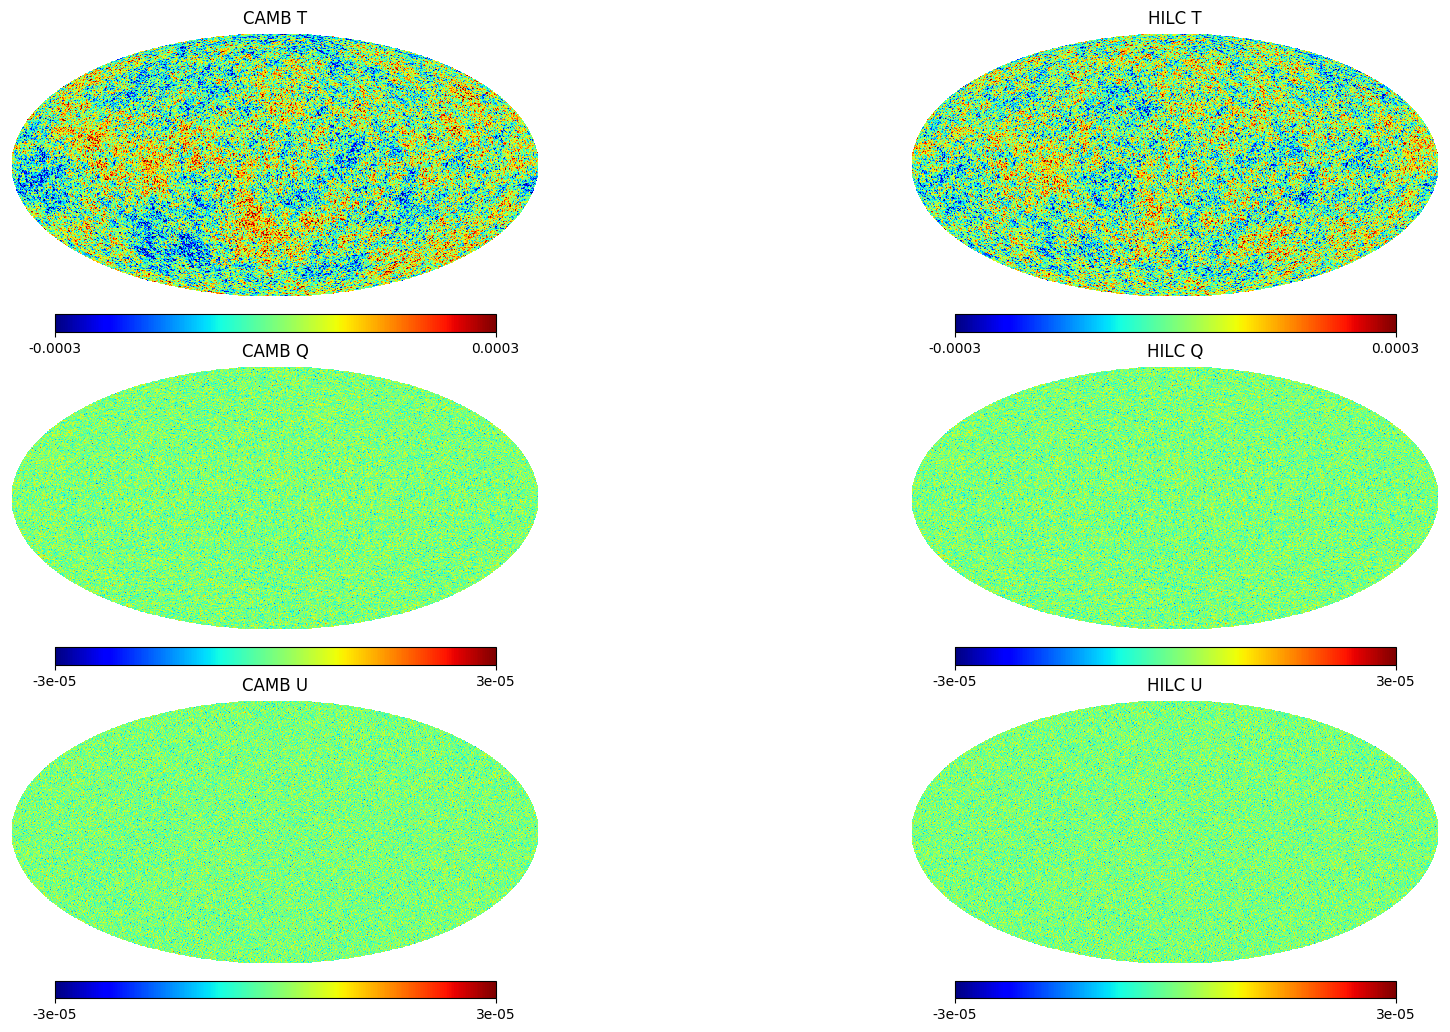

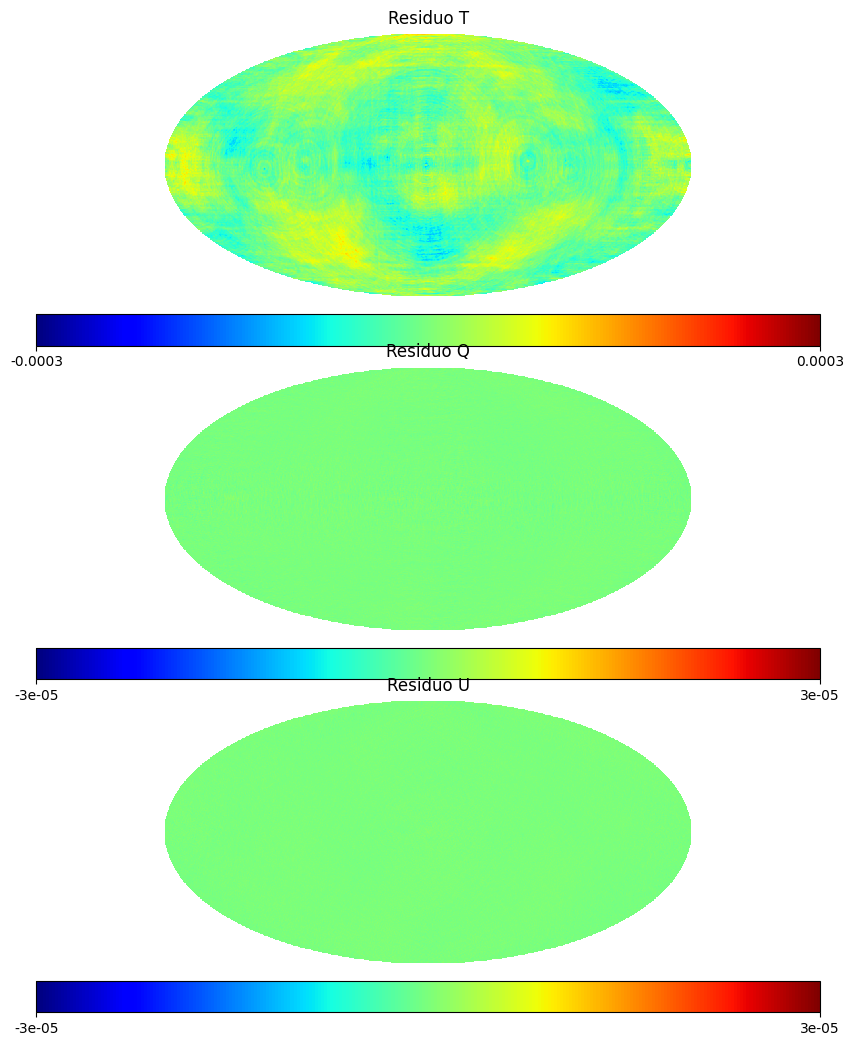

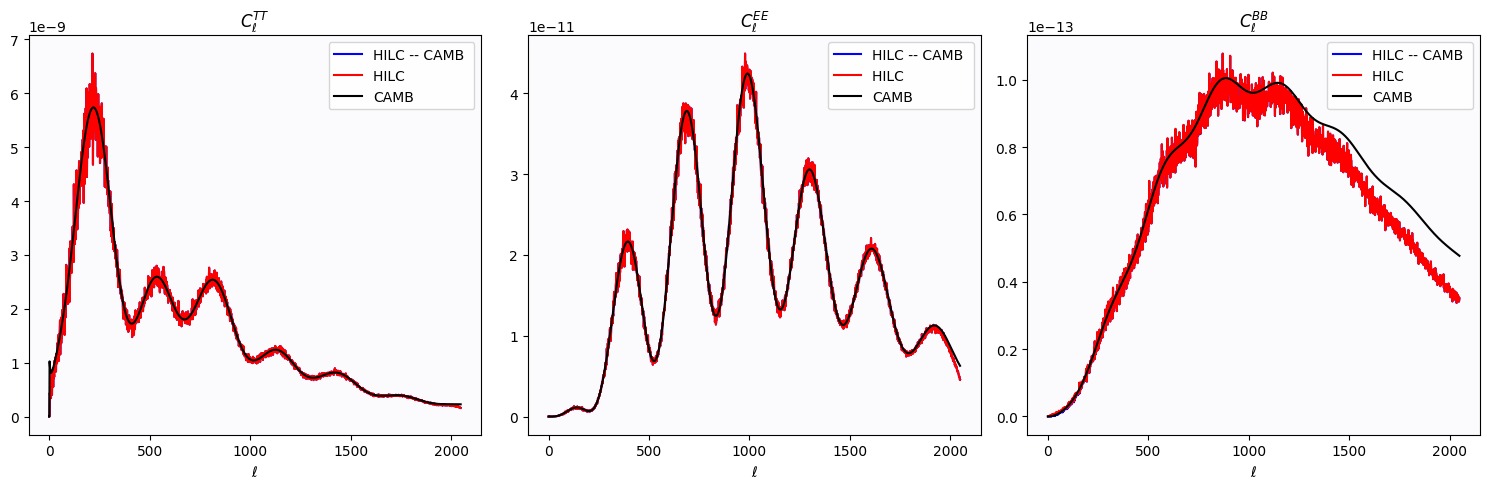

Text(0.5, 1.0, 'Mean residual noise $\\left< N_\\ell \\right>$')

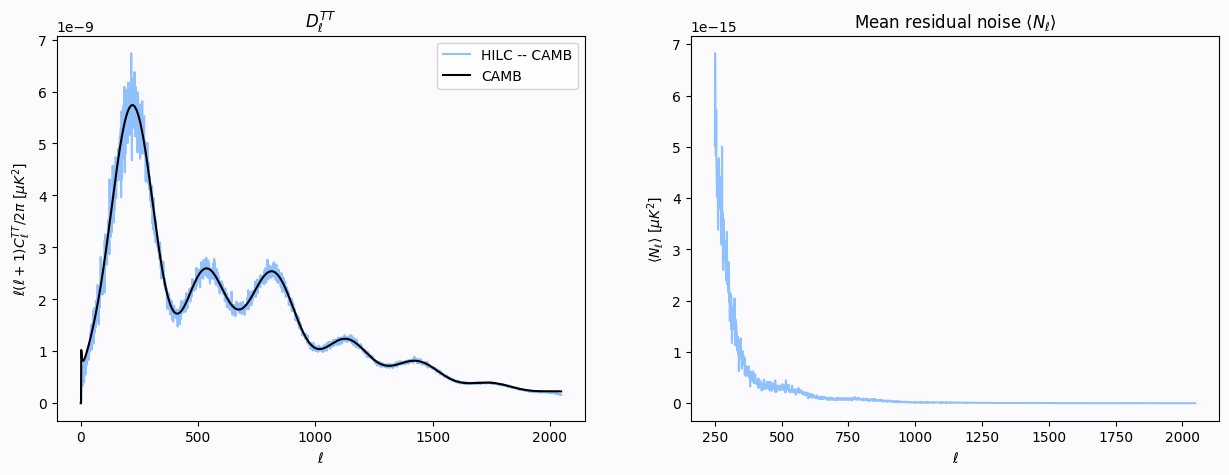

In [ ]:
ruta_HILC = "/home/jorge/Escritorio/Proy_cosmo/Cosmo_MSc/outputs/Filtered_maps/HILC_maps/Full_sky/r_0.0"

ruta = "/home/jorge/Escritorio/Proy_cosmo/Cosmo_MSc/outputs/fiducial/r_0.0"

r_residuo = "/home/jorge/Escritorio/Proy_cosmo/Cosmo_MSc/outputs/Filtered_maps/HILC_residuals/r_0.0"

nside = NSIDE
lmax  = LMAX
nsim  = NSIM

vect_r = np.array([0, 0.01, 0.05, 0.1])
names = np.array(["T", "E" , "B"])

data = np.load(os.path.join(ruta_HILC, f"alms_{5}.npz")) # alm mapas HILC

data1 = np.load(os.path.join(ruta, f"cmb_alms_total{5}.npz")) # alm mapa camb

d_res = np.load(os.path.join(r_residuo, f"mean_residual_cls.npz"))

ells = np.loadtxt(os.path.join(ruta, "ells.txt"))

factor = ells*(ells+1)/(2*np.pi)
alms_camb = []
alms_HILC = []
Cl = []
for name in names:

    tot_cl =  np.loadtxt(os.path.join(ruta, f"Cl_total_{name}{name}.txt")) 
    Cl.append(tot_cl)

    alms1 = data[f"alm{name}"] 
    alms_HILC.append(alms1)

    alms2 = data1[f"alm{name}"] 
    alms_camb.append(alms2)

map_HILC = hp.alm2map(alms_HILC, nside=nside, lmax=lmax ,pol=True)
map_camb = hp.alm2map(alms_camb, nside=nside, lmax=lmax ,pol=True)


fig = plt.figure(figsize=(18, 10))

hp.mollview(map_camb[0], title=f"CAMB T", min=-3e-4, max=3e-4,sub=(3,2,1), cmap = "jet" )
hp.mollview(map_HILC[0], title=f"HILC T", min=-3e-4, max=3e-4,sub=(3,2,2), cmap = "jet")

hp.mollview(map_camb[1], title=f"CAMB Q", min=-3e-5, max=3e-5,sub=(3,2,3), cmap = "jet" )
hp.mollview(map_HILC[1], title=f"HILC Q", min=-3e-5, max=3e-5,sub=(3,2,4), cmap = "jet" )

hp.mollview(map_camb[2], title=f"CAMB U", min=-3e-5, max=3e-5,sub=(3,2,5), cmap = "jet" )
hp.mollview(map_HILC[2], title=f"HILC U", min=-3e-5, max=3e-5,sub=(3,2,6), cmap = "jet" )

plt.show()

### Residuo nivel mapa
map_res = map_HILC - map_camb

fig = plt.figure(figsize=(18, 10))
hp.mollview(map_res[0], title=f"Residuo T", min=-3e-4, max=3e-4,sub=(3,1,1), cmap = "jet" )
hp.mollview(map_res[1], title=f"Residuo Q", min=-3e-5, max=3e-5,sub=(3,1,2), cmap = "jet" )
hp.mollview(map_res[2], title=f"Residuo U", min=-3e-5, max=3e-5,sub=(3,1,3), cmap = "jet" )
plt.show()


fig, ax = plt.subplots(1, 3, figsize=(15, 5))
for j,name in enumerate(names):

    ax[j].set_facecolor("#fbfbfe")

    Cl_camb = hp.sphtfunc.alm2cl(alms_camb, alms_camb, lmax=lmax)*factor
    Cl_HILC = hp.sphtfunc.alm2cl(alms_HILC, alms_HILC, lmax=lmax)*factor
    Cl_HILC_camb = hp.sphtfunc.alm2cl(alms_camb, alms_HILC, lmax=lmax)*factor

    # ax[j].plot(ells, Cl[j], label="CAMB", color="b")

    #ax[j].plot(ells, Cl_HILC_camb[j], label="HILC -- CAMB ", color="b")

    ax[j].plot(ells, Cl_HILC[j], label="HILC ", color="r")
    
    ax[j].plot(ells, Cl[j]*factor, label="CAMB", color="black")

    ax[j].legend()
    ax[j].set_xlabel(r'$\ell$')
    ax[j].set_title(rf'$C_\ell ^{{{name}{name}}}$')

plt.tight_layout()
plt.show()

mean_Nl = np.zeros((3, lmax+1))
for i in range(nsim):

    data2 = np.load(os.path.join(ruta_HILC, f"Nl_HILC{i+1}.npz")) # ruido residual de los mapas HILC

    for j,name in enumerate(names):

        mean_Nl[j] += data2[f"N{name}"]

mean_Nl /= NSIM

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
fig.patch.set_facecolor("#fbfbfe")
ax[0].set_facecolor("#fbfbfe")
ax[0].plot(ells, Cl_HILC_camb[0], label="HILC -- CAMB", color="#91c0ff")
ax[0].plot(ells, Cl[0]*factor, label="CAMB", color="black")
ax[0].legend()
ax[0].set_xlabel(r'$\ell$')
ax[0].set_ylabel(r'$\ell(\ell+1)C_{\ell}^{TT} / 2\pi$ [$\mu K^2$]')
ax[0].set_title(r'$D_\ell^{TT}$')

ax[1].set_facecolor("#fbfbfe")
#ax[1].plot(ells[15:], mean_Nl[0][15:],color="#91c0ff")
ax[1].plot(ells[250:], d_res["TT"][250:],color="#91c0ff")
ax[1].set_xlabel(r'$\ell$')
ax[1].set_ylabel(r'$\left< N_\ell \right> $ [$\mu K^2$]')
ax[1].set_title(r"Mean residual noise $\left< N_\ell \right>$")








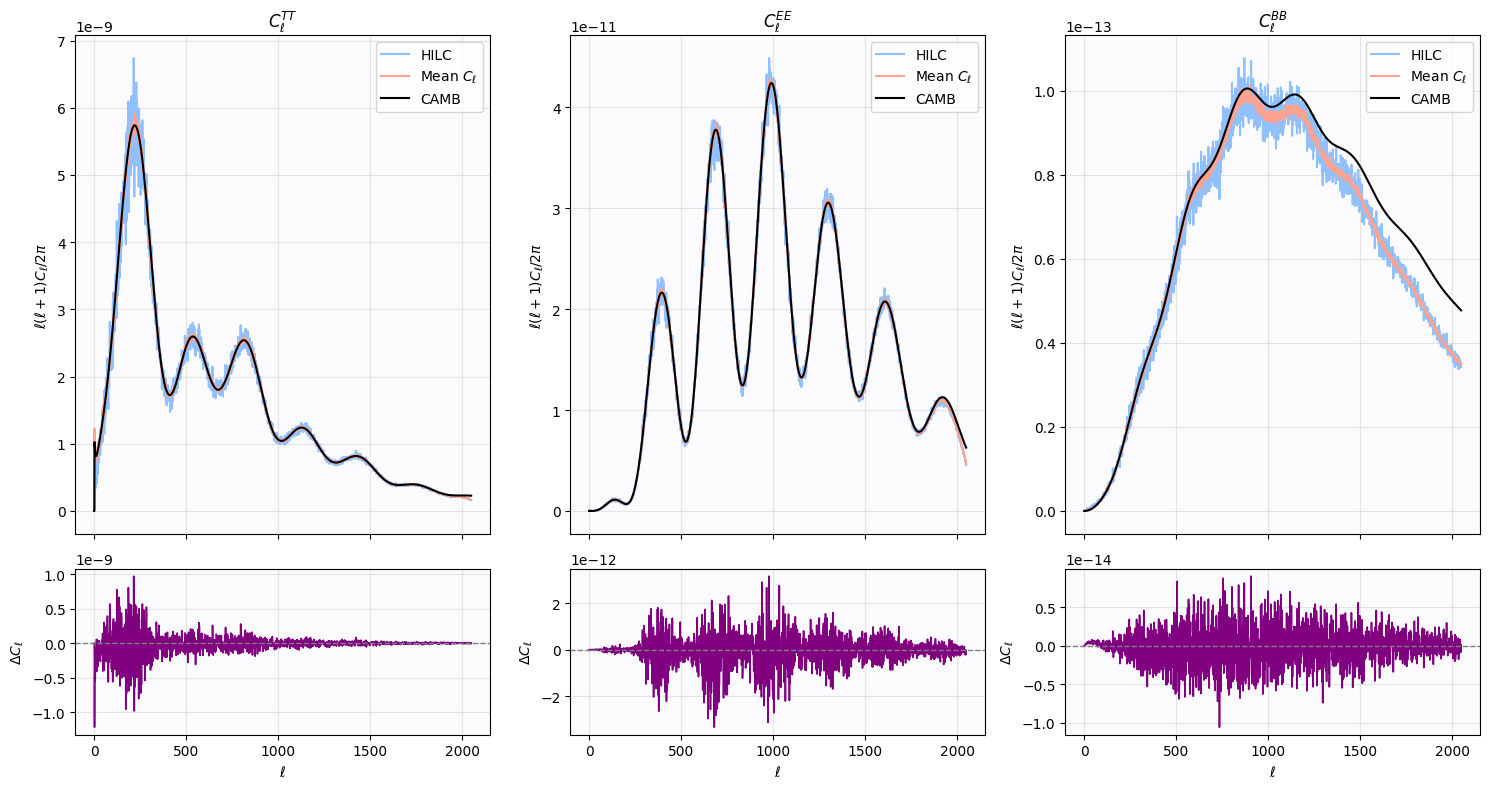

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp

ruta_HILC = "/home/jorge/Escritorio/Proy_cosmo/Cosmo_MSc/outputs/Filtered_maps/HILC_maps/Full_sky/r_0.0"

ruta = "/home/jorge/Escritorio/Proy_cosmo/Cosmo_MSc/outputs/fiducial/r_0.0"

r_residuo = "/home/jorge/Escritorio/Proy_cosmo/Cosmo_MSc/outputs/Filtered_maps/HILC_residuals/r_0.0"

nside = NSIDE
lmax  = LMAX
nsim  = NSIM

vect_r = np.array([0, 0.01, 0.05, 0.1])
names = np.array(["T", "E" , "B"])
names1 = np.array(["TT", "EE", "BB", "TE"])

Cl_total = []
for name in names1:
    tot_cl =  np.loadtxt(os.path.join(ruta, f"Cl_total_{name}.txt"))
    Cl_total.append(tot_cl)

data = np.load(os.path.join(ruta_HILC, f"alms_{5}.npz")) # alm mapas HILC

mean_Cl_TT = np.loadtxt(os.path.join(ruta, f"Mean_Cl_ls_TT.txt")) 
mean_Cl_EE = np.loadtxt(os.path.join(ruta, f"Mean_Cl_ls_EE.txt")) 
mean_Cl_BB = np.loadtxt(os.path.join(ruta, f"Mean_Cl_ls_BB.txt")) 

mean_Cl = [mean_Cl_TT, mean_Cl_EE, mean_Cl_BB]

d_res = np.load(os.path.join(r_residuo, f"mean_residual_cls.npz"))

ells = np.loadtxt(os.path.join(ruta, "ells.txt"))

factor = ells*(ells+1)/(2*np.pi)
alms_camb = []
alms_HILC = []
Cl = []
for name in names:

    tot_cl =  np.loadtxt(os.path.join(ruta, f"Cl_total_{name}{name}.txt")) 
    Cl.append(tot_cl)

    alms1 = data[f"alm{name}"] 
    alms_HILC.append(alms1)

    alms2 = data1[f"alm{name}"] 
    alms_camb.append(alms2)

n_spec = len(names)

fig, axes = plt.subplots(
    2, n_spec,
    figsize=(5*n_spec, 8),
    sharex='col',
    gridspec_kw={'height_ratios': [3, 1]}
)

# Si solo hay un espectro, axes no sale con forma (2, n_spec)
if n_spec == 1:
    axes = np.array(axes).reshape(2, 1)

# Calcula todos los Cl
Cl_HILC = hp.alm2cl(alms_HILC, alms_HILC, lmax=lmax) * factor


for j, name in enumerate(names):
    ax_main = axes[0, j]
    ax_res  = axes[1, j]

    Cl_res_frac = np.zeros_like(mean_Cl[j])
    mask = mean_Cl[j] != 0
    Cl_res_frac[mask] = (Cl_HILC[j][mask] - mean_Cl[j][mask]) #/ mean_Cl[j][mask]

    ax_main.set_facecolor("#fbfbfe")
    ax_res.set_facecolor("#fbfbfe")

    # Panel superior
    ax_main.plot(ells, Cl_HILC[j], label="HILC", color="#91c0ff", lw=1.5)
    ax_main.plot(ells, mean_Cl[j], label=r"Mean $C_\ell$", color="#ffa391", lw=1.5)
    ax_main.plot(ells, Cl_total[j]*factor, label="CAMB", color="black", lw=1.5)


    ax_main.set_title(rf"$C_\ell^{{{name}{name}}}$")
    ax_main.set_ylabel(r"$\ell(\ell+1)C_\ell/2\pi$")
    ax_main.grid(True, alpha=0.3)
    ax_main.legend()

    # Panel inferior: diferencia absoluta
    ax_res.plot(ells, Cl_res_frac, color="purple", lw=1.2)
    ax_res.axhline(0, color="gray", ls="--", lw=1)

    ax_res.set_xlabel(r"$\ell$")
    ax_res.set_ylabel(r"$\Delta C_\ell$")
    ax_res.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Wiener Filter y C-Inverse

Estoy usando la aproximacion de LiteBIRD, donde aproximan el filtro de la siguiente forma:

$$ X_{\ell,m}^{CI} \approx \frac{X_{\ell,m}^{data}}{C_{\ell}^{XX} + \left < N_{\ell}^{XX} \right>} $$

Siempre y cuando ignoremos el filtro de TE. SO no lo hace asi, ellos resuelven esta ecuacion ...


Pero visualicemos esta aproximacion.

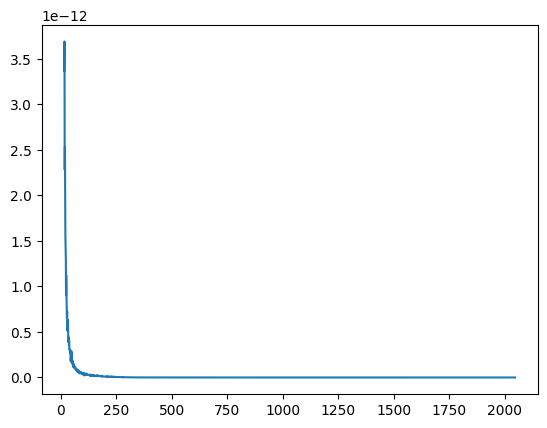

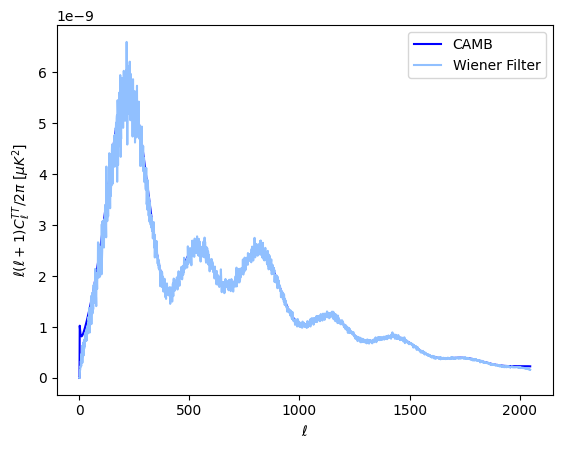

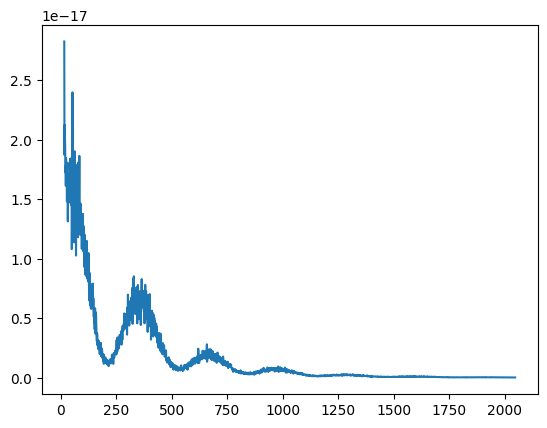

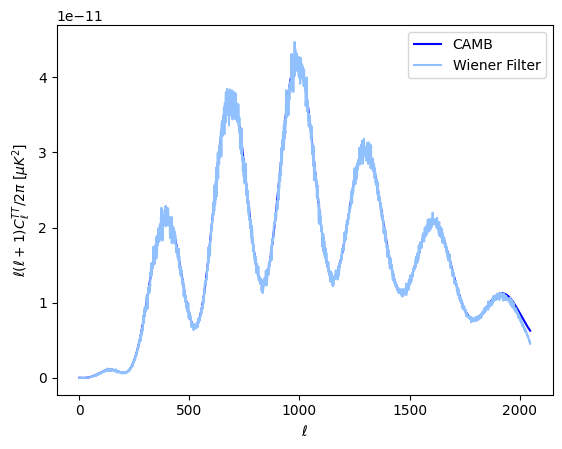

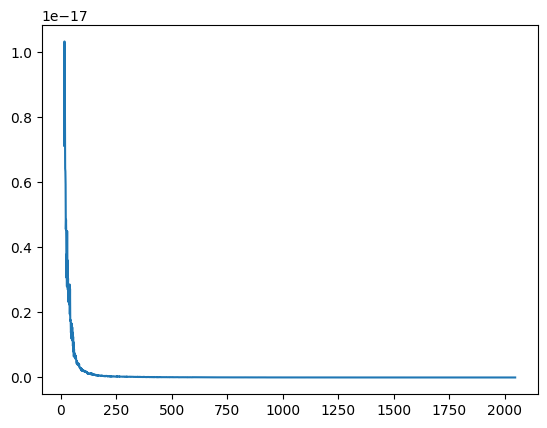

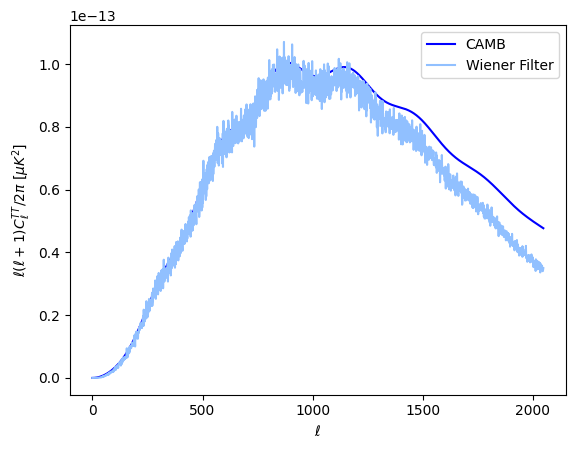

In [5]:

ruta = "/home/jorge/Escritorio/Proy_cosmo/Cosmo_MSc/outputs/fiducial/r_0.0"

ruta_HILC = "/home/jorge/Escritorio/Proy_cosmo/Cosmo_MSc/outputs/Filtered_maps/HILC_maps/Full_sky/r_0.0"

ruta_WF = "/home/jorge/Escritorio/Proy_cosmo/Cosmo_MSc/outputs/Filtered_maps/W_filter/r_0.0"

r_residuo = "/home/jorge/Escritorio/Proy_cosmo/Cosmo_MSc/outputs/Filtered_maps/HILC_residuals/r_0.0"

d_res = np.load(os.path.join(r_residuo, f"mean_residual_cls.npz"))


nside = NSIDE
lmax  = LMAX
nsim  = NSIM

names = np.array(["T", "E" , "B"])

data = np.load(os.path.join(ruta_HILC, f"alms_{5}.npz")) # alm mapas HILC

data_Noise = np.load(os.path.join(ruta_HILC, f"Mean_Nl.npz"))

data1 = np.load(os.path.join(ruta, f"cmb_alms_total{5}.npz")) # alm mapa camb

ells = np.loadtxt(os.path.join(ruta, "ells.txt"))

data_N = np.load(os.path.join(ruta_WF, f"WF_{5}.npz"))

factor = ells*(ells+1)/(2*np.pi)

for name in names:

    tot_cl =  np.loadtxt(os.path.join(ruta, f"Cl_total_{name}{name}.txt"))

    alm_HILC = data[f"alm{name}"]
    
    WF_func = data_N[f"W_{name}"]
    
    alm_filt = hp.almxfl(alm_HILC, WF_func )

    Nl = d_res[f"{name}{name}"]

    plt.plot(ells[15:], Nl[15:])
    plt.show()


    #Calcular los Cl con los alm filtrados

    Cl = hp.alm2cl(alm_filt,alm_filt)

    plt.plot(ells, tot_cl*factor, color="b", label="CAMB")
    plt.plot(ells, Cl*factor, color="#91c0ff",label="Wiener Filter")
    plt.xlabel(r'$\ell$')
    plt.ylabel(r'$\ell(\ell+1)C_{\ell}^{TT} / 2\pi$ [$\mu K^2$]')
    plt.legend(loc="upper right")
    plt.show()




In [ ]:
#hp.mollview(map_camb[0], title=f"CAMB T", min=-3e-4, bgcolor="#fbfbfe",max=3e-4,sub=(3,2,1), cmap = "jet")

hp.mollview(map_HILC[0], title=f"HILC T", min=-3e-4, bgcolor="#fbfbfe", max=3e-4,sub=(3,2,2), cmap = "jet")

plt.savefig(
    "HILC_transparente.png",
    dpi=300,
    transparent=True,
    bbox_inches="tight",
    pad_inches=0
)
plt.close()
# plt.savefig(
#     "cmb_transparente.png",
#     dpi=300,
#     transparent=True,  # ← CLAVE
#     bbox_inches="tight"
# )


# Cmblensplus

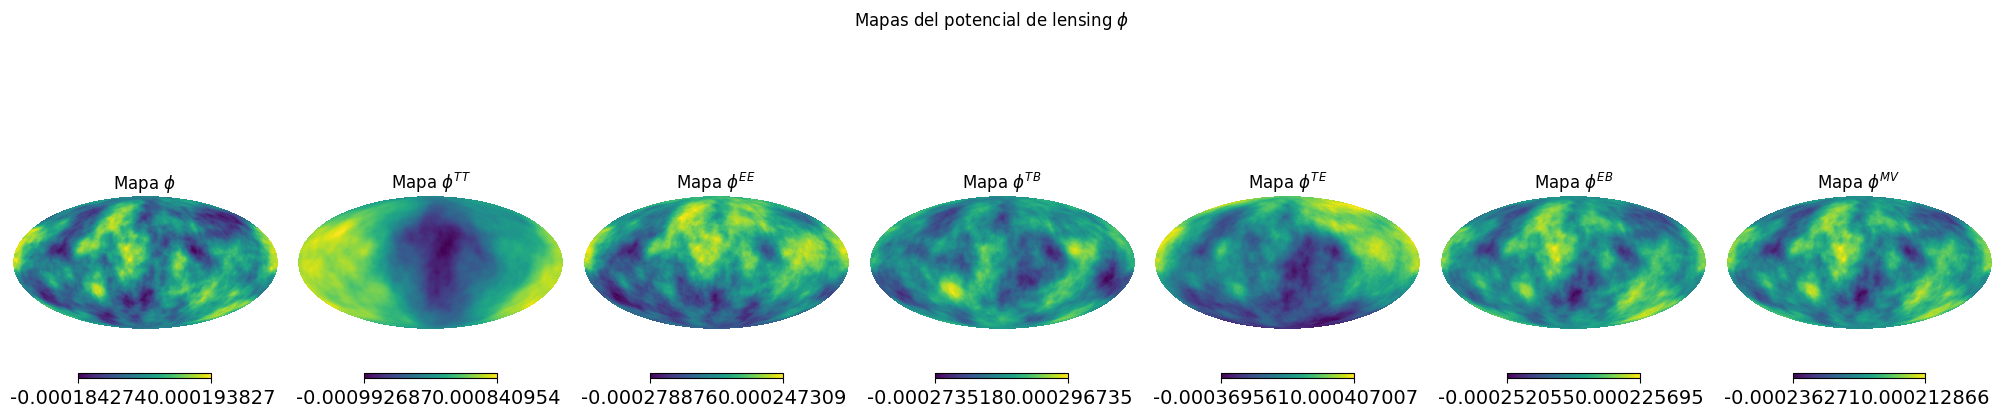

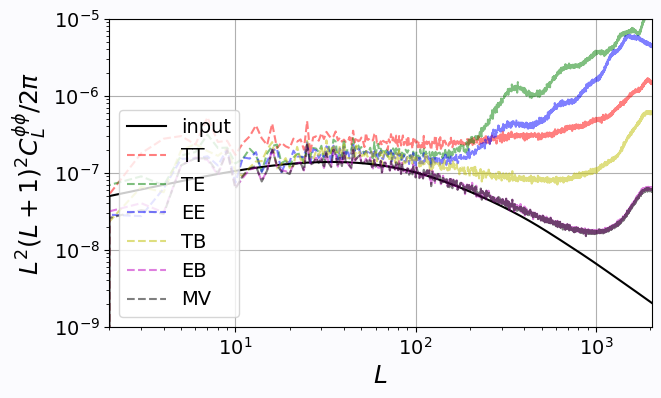

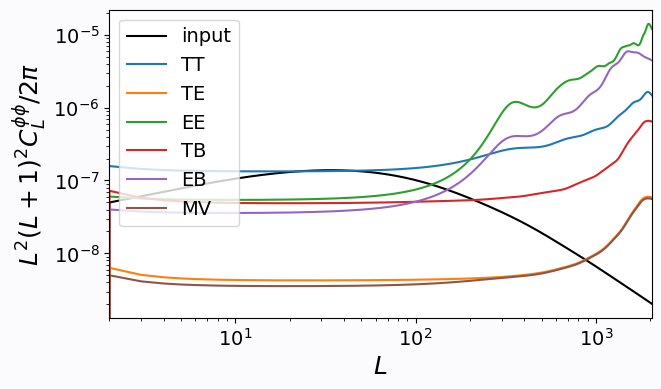

In [14]:
from curvedsky import delens, utils
import plottools as pl
from matplotlib.pyplot import *

ruta = "/home/jorge/Escritorio/Proy_cosmo/Cosmo_MSc/outputs/rec_lensing/r_0.0"

ruta_f = "/home/jorge/Escritorio/Proy_cosmo/Cosmo_MSc/outputs/fiducial/r_0.0"

nside = NSIDE
lmax  = LMAX
nsim  = NSIM

elmin, elmax = 100, lmax
rlmin, rlmax = 100, lmax

L = np.linspace(0,lmax,lmax+1)
Lfac = (L*(L+1))**2/(2*np.pi)

names = np.array(["TT", "EE", "TB", "TE", "EB","MV"])

Cl_phi = np.loadtxt(os.path.join(ruta_f, f"Cl_phiphi.txt")) 

data2 = np.load(os.path.join(ruta_f, f"cmb_alms_phi{5}.npz")) # cargar phi
alm_phi = data2["alm_phi"]

map_phi = hp.alm2map(alm_phi, nside=nside, lmax=lmax)

data = np.load(os.path.join(ruta, f"rec_pot_{5}.npz"))

data_norm = np.load(os.path.join(ruta, f"rec_norm_{5}.npz"))

plt.figure(figsize=(20,18))
plt.suptitle(r"Mapas del potencial de lensing $\phi$",y=0.75)
hp.mollview(map_phi, title=rf"Mapa $\phi$", sub=(2,7,1)) #min=-3e-4, max=3e-4,

gg, Ag, cc = {}, {}, {}

for i, name in enumerate(names):

    Ag[name] = data_norm[f"ag{name}"]

    glm = data[f"glm{name}"]

    gg[name] = utils.alm2cl(lmax,glm)

    map = utils.hp_alm2map(nside=nside,lmax=lmax,mmax=lmax,alm=glm)

    hp.mollview(map, title=rf"Mapa $\phi^{{{name}}}$", sub=(2,7,i+2)) # min=-3e-4, max=3e-4,

plt.show()


# plot spectra (gradient)
figure(facecolor="#fbfbfe")
pl.plot_1dstyle(fsize=[7,4],xmin=2,xmax=lmax,xlog=True,ylog=True,ymin=1e-9,ymax=1e-5,grid=True,ylab=r'$L^2(L+1)^2C^{\phi\phi}_L/2\pi$') #ymin=1e-9,ymax=1e-6
plot(L,Lfac*Cl_phi,color="black",ls='-',label='input')
for qi, (c, q) in enumerate([('r','TT'),('g','TE'),('b','EE'),('y','TB'),('m','EB'),('k','MV')]):
    plot(L,Lfac*gg[q],color=c,ls='--',label=q,alpha=.5)
    # plot(L,Lfac*Ag[qi,:],color=c,ls='-')
legend(loc="lower left")

# plot normalization (gradient)
figure(facecolor="#fbfbfe")
pl.plot_1dstyle(fsize=[7,4],xmin=2,xmax=lmax,xlog=True,ylog=True,ylab=r'$L^2(L+1)^2C^{\phi\phi}_L/2\pi$')
plot(L,Lfac*Cl_phi,color="black",ls='-',label='input')
for qi, q in enumerate(['TT','TE','EE','TB','EB','MV']):
    plot(L,Ag[q]*Lfac,label=q)
legend()

# glm = data[f"glmMV"]

# ruta_HILC = "/home/jorge/Escritorio/Proy_cosmo/Cosmo_MSc/outputs/Filtered_maps/HILC_maps/Full_sky/r_0.0"

# ruta_W ="/home/jorge/Escritorio/Proy_cosmo/Cosmo_MSc/outputs/Filtered_maps/W_filter/r_0.0"

# data = np.load(os.path.join(ruta_HILC, f"alms_{5}.npz"))

# data_1 = np.load(os.path.join(ruta_W, f"WF_{5}.npz"))

# W_l = data_1["W_E"]

# Ealm = utils.lm_healpy2healpix(data["almE"], lmax=lmax)

# Ealm *= W_l

# lalm = delens.lensingb(lmax,elmin,elmax,rlmin,rlmax,Ealm[:elmax+1,:elmax+1],glm[:rlmax+1,:rlmax+1])


